In [1]:
import pandas as pd

dc = pd.read_csv('datacenters.csv')

print(dc.shape)          # how many rows and columns
print(dc.columns.tolist())   # what columns exist
print(dc.head())         # first 5 rows

(18110, 6)
['name', 'company', 'city', 'state', 'country', 'address']
                         name             company         city state  \
0  NAP de las Americas Madrid           Terremark       Madrid   NaN   
1            Central Office 2        StarHub Ltd.    Singapore   NaN   
2                 Cluj-Napoca     GTS Telecom SRL  Cluj-Napoca   NaN   
3               Etix Accra #1     Etix Everywhere        Accra   NaN   
4                   Karlsruhe  1&1 Internet, Inc.    Karlsruhe   NaN   

     country                                       address  
0      Spain         Calle de Yecora, 4 28009 Madrid Spain  
1  Singapore     19 Tai Seng Dr 535222 Singapore Singapore  
2    Romania  Str. Garii nr. 21 400267 Cluj-Napoca Romania  
3      Ghana                               R40 Accra Ghana  
4    Germany       Brauerstraße 48 76135 Karlsruhe Germany  


In [2]:
# Top 10 countries by data center count
print(dc['country'].value_counts().head(10))

# Filter to just the United States
us = dc[dc['country'] == 'United States'].copy()
print("\nUS data centers:", len(us))

United States     8818
United Kingdom     747
Germany            584
France             558
China              548
Netherlands        444
Canada             415
Australia          396
India              342
Brazil             298
Name: country, dtype: int64

US data centers: 8818


In [3]:
# The state column is messy: 'VA' vs 'Virginia' vs 'TX' vs 'Texas'
# and some rows even have CITY names in the state column!

state_map = {'California':'CA','Texas':'TX','Virginia':'VA','New York':'NY',
 'Florida':'FL','Georgia':'GA','Arizona':'AZ','Illinois':'IL','Washington':'WA',
 'Oregon':'OR','Ohio':'OH','New Jersey':'NJ','Colorado':'CO','North Carolina':'NC',
 'Pennsylvania':'PA','Massachusetts':'MA','Maryland':'MD','Tennessee':'TN'}

city_to_state = {'Phoenix':'AZ','Chicago':'IL','Dallas':'TX','Atlanta':'GA',
 'Ashburn':'VA','Sterling':'VA','Manassas':'VA','Santa Clara':'CA','Houston':'TX',
 'Austin':'TX','Seattle':'WA','Denver':'CO','Miami':'FL','Portland':'OR',
 'Las Vegas':'NV','New York':'NY','San Jose':'CA','Charlotte':'NC'}

def clean_state(row):
    s = str(row['state']).strip()
    if s in state_map: return state_map[s]
    if len(s) == 2 and s.upper() in state_map.values(): return s.upper()
    if s in city_to_state: return city_to_state[s]
    if str(row['city']).strip() in city_to_state: return city_to_state[str(row['city']).strip()]
    return None

us['state_clean'] = us.apply(clean_state, axis=1)

before = len(us)
us = us.dropna(subset=['state_clean'])   # drop rows we couldn't fix
after = len(us)

print("Before cleaning:", before)
print("After cleaning:", after)
print("Kept:", round(after/before*100), "%")

Before cleaning: 8818
After cleaning: 3814
Kept: 43 %


In [4]:
# Top 10 states
print(us['state_clean'].value_counts().head(10))

# Top 10 companies operating in the US
print(us['company'].value_counts().head(10))

VA    809
TX    677
CA    397
GA    315
IL    310
AZ    262
NY    196
FL    131
OH    118
WA    103
Name: state_clean, dtype: int64
Amazon AWS              125
Microsoft               108
Digital Realty Trust    103
Equinix                 100
DataBank                 96
Digital Realty           90
Amazon                   70
CenturyLink              66
EdgeConneX               58
QTS Data Centers         53
Name: company, dtype: int64


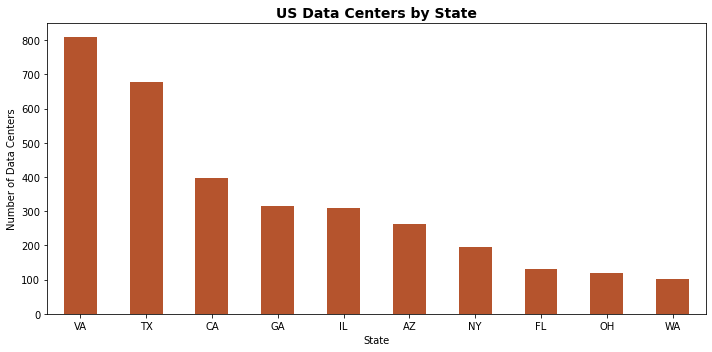

In [5]:
import matplotlib.pyplot as plt

top_states = us['state_clean'].value_counts().head(10)

top_states.plot(kind='bar', color='#B5542D', figsize=(10, 5))
plt.title('US Data Centers by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Data Centers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_states.png')   # saves the image next to your notebook
plt.show()